## Traffic Modeling
#### Starter Pack

In [1]:
import gzip
import struct
import pandas as pd

records = []

#Opens file "TR1.gz" given in assignment PDF
with gzip.open("TR1.gz", "rb") as f:
#with open(file_path, "rb") as f: #if it is autoDecompressed in your MACOS
    while True:
        data = f.read(20)
        if len(data) < 20:
            break

        #Interprets the web traffic that occurred once we took off the quotation marks   
        timestamp, client, obj, size, method, status, file_type, server = \
        struct.unpack(">IIIIBBBB", data)
        records.append([
        timestamp, client, obj, size,
        method, status, file_type, server
        ])

        #Probability and Statistical Modeling of Web Traffic 3

#Puts the interpreted traffic into a readable format
df = pd.DataFrame(records, columns=[
        "timestamp", "client_id", "object_id", "size",
        "method", "status", "type", "server"
        ])
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)


#Prints the web traffic that occurred
print(df.head())
print(df.shape)


#"Interarrival time between consecutive requests"
df["interarrival_time"] = df["timestamp"].diff()

#"Number of requests per minute"
df["minute"] = df["datetime"].dt.floor("min")
requests_per_minute = df.groupby("minute").size().reset_index(name="request_count")

#Preprocessing is complete above!

   timestamp  client_id  object_id  size  method  status  type  server  \
0  895615201      14275       6219   546       0      66     1      99   
1  895615201       3817        233   631       0      66     1      99   
2  895615201      28686        981  3717       0      66     1      99   
3  895615201     385403        403   993       0      66     1      99   
4  895615201     403925         56  2140       0     130     1      99   

                   datetime  
0 1998-05-19 22:00:01+00:00  
1 1998-05-19 22:00:01+00:00  
2 1998-05-19 22:00:01+00:00  
3 1998-05-19 22:00:01+00:00  
4 1998-05-19 22:00:01+00:00  
(3041727, 9)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb, factorial, exp

np.random.seed(42)

def display_distribution_table(x_values, pmf_values):
    """Return a table with x, PMF, and CDF."""
    df = pd.DataFrame({
        "x": x_values,
        "P(X=x)": pmf_values
    })
    df["F(x)=P(X<=x)"] = df["P(X=x)"].cumsum()
    return df

def plot_pmf(x_values, pmf_values, title, xlabel="x"):
    plt.figure(figsize=(7, 4))
    plt.bar(x_values, pmf_values, color="steelblue", edgecolor="black")
    plt.xlabel(xlabel)
    plt.ylabel("P(X = x)")
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

def plot_cdf(x_values, cdf_values, title, xlabel="x"):
    plt.figure(figsize=(7, 4))
    plt.step(x_values, cdf_values, where="post", color="darkorange", linewidth=2)
    plt.xlabel(xlabel)
    plt.ylabel("F(x) = P(X <= x)")
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.grid(linestyle="--", alpha=0.7)
    plt.show()


In [3]:
df["type"].value_counts()

type
1     2599255
0      357362
10      47066
4       26098
12       5951
8        4468
3         839
7         484
6         100
2          98
9           4
5           2
Name: count, dtype: int64

In [4]:

A = df["type"] == 1
A

0           True
1           True
2           True
3           True
4           True
           ...  
3041722    False
3041723    False
3041724     True
3041725     True
3041726     True
Name: type, Length: 3041727, dtype: bool

df.value_counts

### Part 1 - Probability from Observed Events

In [5]:
# A = request belongs to category 1 (type == 1)
# B = object size is exceeds a chosen threshold (greater then the 75th percentile)

A = df["type"] == 1

threshold = df["size"].quantile(0.75)

B = df["size"] > threshold

print("\nThreshold for B:", threshold)

# 1. Estimate P(A), P(B), P(A ∩ B), and P(A ∪ B). Verify the addition rule numerically.
P_A = A.mean()
P_B = B.mean()

# P(A ∩ B)
P_A_and_B = (A & B).mean()
# P(A ∪ B)
P_A_or_B = (A | B).mean()

# Addition rule says that P(A ∪ B) = P(A) + P(B) - P(A ∩ B)
P_A_or_B_addition_rule = (P_A + P_B) - (P_A_and_B) 

print("\n----- Part 1.1 P(A), P(B), P(A ∩ B), P(A ∪ B) and Addition rule -----")
print("P(A):", P_A)
print("P(B):", P_B)
print("P(A ∩ B):", P_A_and_B)
print("P(A ∪ B):", P_A_or_B)
print("Addition rule:", P_A_or_B_addition_rule)

# 2. Estimate P(A | B) and P(B | A). Interpret both probabilities in the context of web requests.
# This are just basically conditional probabilities
P_A_given_B = (P_A_and_B)/(P_B)
P_B_given_A = (P_A_and_B)/(P_A)

print("\n----- Part 1.2 Conditional Probabilities ----- ")
print("P(A | B):", P_A_given_B)
print("P(A | B):", P_B_given_A)

# 3. Investigate whether A and B appear independent. Support your conclusion with numerical evidence.
# We learn in class that Events A and B are independent if any one of the following holds:
# P(A|B) = P(A), P(B|A) = P(B), P(A ∩ B) = P(A)P(B)

P_A_times_P_B = P_A * P_B
print("\n----- Part 1.3 Whether A And B Appear Independent ----- ")
print("Check 1")
print("P(A ∩ B):", P_A_and_B)
print("P(A)P(B):", P_A_times_P_B)
print("Difference:", round(abs(P_A_and_B - P_A_times_P_B),4))

print("\nCheck 2")
print("P(A|B):", P_A_given_B)
print("P(A):", P_A)
print("Difference:", round(abs(P_A_and_B - P_A),4))


print("\nCheck 3")
print("P(B|A):", P_B_given_A)
print("P(B):", P_B)
print("Difference:", round(abs(P_B_given_A - P_B),4))


# 3. Partition requests into several request categories
# Partition requests by type (C) and use it to get P(B)
# P(B) = ∑ P(B|C) * P(C)

P_B_total = 0

print("\n----- 4. Law of total probability ----- ")

for category in df["type"].unique():

    # Here C gets True/False value and get the probability of true
    C = df["type"] == category
    P_C = C.mean()

    # This keeps only the row where C is also true, 
    # we do this because we are looing for the likeliness of a B in given C
    # B has it own True/False list, but we use C as a filter to find type 1 category
    # and calculate the probability from there
    
    P_B_given_C = B[C].mean()

    contribution = P_B_given_C * P_C
    P_B_total += contribution

    print("\nCategory:", category)
    print("P(C):", P_C)
    print("P(B|C):", P_B_given_C)
    print("P(B|C)P(C):", contribution)

print("\nP(B):", P_B)
print("P(B) using total probability law:", P_B_total)

# 4. Bayes’ theorem to compute the probability 
# Formula: P(C | B) = P(B | C)P(C) / P(B)

selected_category = 1

#This gives C a value of True/ False
C = df["type"] == selected_category

P_C = C.mean()
P_B_given_C = B[C].mean()

P_C_given_B_bayes = (P_B_given_C * P_C) / P_B

# Measured directly
P_C_given_B_direct = (C & B).sum() / B.sum()

print("\n ----- 5. Bayes Theorem -----")
print("Selected category:", selected_category)
print("P(C):", P_C)
print("P(B|C):", P_B_given_C)
print("P(B):", P_B)
print("P(C | B) using Bayes' theorem =", P_C_given_B_bayes)
print("P(C | B) measured directly =", P_C_given_B_direct)
print("Difference =", abs(P_C_given_B_bayes - P_C_given_B_direct))






Threshold for B: 10312.0

----- Part 1.1 P(A), P(B), P(A ∩ B), P(A ∪ B) and Addition rule -----
P(A): 0.8545326388594374
P(B): 0.24995208314224124
P(A ∩ B): 0.19796878549587127
P(A ∪ B): 0.9065159365058074
Addition rule: 0.9065159365058074

----- Part 1.2 Conditional Probabilities ----- 
P(A | B): 0.7920269477538716
P(A | B): 0.2316690744078592

----- Part 1.3 Whether A And B Appear Independent ----- 
Check 1
P(A ∩ B): 0.19796878549587127
P(A)P(B): 0.2135922131959529
Difference: 0.0156

Check 2
P(A|B): 0.7920269477538716
P(A): 0.8545326388594374
Difference: 0.6566

Check 3
P(B|A): 0.2316690744078592
P(B): 0.24995208314224124
Difference: 0.0183

----- 4. Law of total probability ----- 

Category: 1
P(C): 0.8545326388594374
P(B|C): 0.23166907440785917
P(B|C)P(C): 0.19796878549587124

Category: 0
P(C): 0.11748654629425981
P(B|C): 0.38299259574325195
P(B|C)P(C): 0.044996477330148305

Category: 10
P(C): 0.015473446499307795
P(B|C): 0.09119109335826286
P(B|C)P(C): 0.0014110405042924627

Cat

<pre>
Part 2 - Discrete Random Variables and Distributions
Create equal time intervals (for example, 1-minute intervals) and define X = number of requests arriving in one
interval.
6. Construct the empirical probability mass function (PMF) of X.
7. Construct the empirical CDF of X and use it to estimate probabilities such as P(X ≤ x) and P(a < X ≤ b).
8. Calculate the sample mean and variance of X.
9. Fit a Poisson model to X by estimating λ from the data. Compare the observed mean, observed variance, and
empirical frequencies with the theoretical Poisson model.
10. Define a binary request event and estimate its probability p. For groups of n requests, use a Binomial model
to calculate the probability of exactly k events, no events, and at least one event.
11. Define Y as the number of requests until the first occurrence of your selected event. Use a Geometric
distribution to model Y and compare the theoretical and empirical means.
12. Extend the previous question to the number of requests required to observe the third occurrence of the
event. Identify the appropriate distribution and calculate its expected value.

</pre>

1.0
19


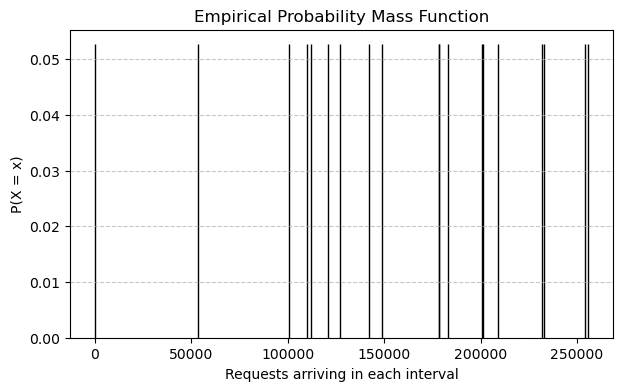

In [6]:
import matplotlib.pyplot as plt
import numpy as np

## choose larger value to reduce the count of x_values
time_interval = 5000


df["interarrival_time"] = df["timestamp"].diff()
print(df["interarrival_time"].max())
df["timestamp"].max()

X =  [ ]
a_val = []
start = 895615201
interval_value = 895615201
end = 895701598
a = True

while start <= end:
    interval_value += time_interval
    if interval_value > end and a:
        interval_value = end
        a = False

    a_val.append(interval_value)
    X.append(((df["timestamp"] >= start) & (df["timestamp"] < interval_value)).sum())

    start = interval_value
# print(X)


print(len(X))

x_values, counts = np.unique(X, return_counts =True)

pmf_values = counts / len(X)

# Q6. Construct the empirical probability mass function (PMF) of X.


plot_pmf(x_values, pmf_values, "Empirical Probability Mass Function" , "Requests arriving in each interval")





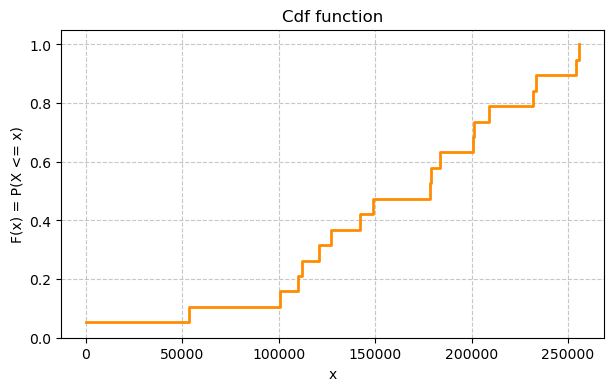

In [7]:
# 7. Construct the empirical CDF of X and use it to estimate probabilities such as P(X ≤ x) and P(a < X ≤ b).


cdf_values = pmf_values.cumsum()

plot_cdf(x_values, cdf_values, "Cdf function")

In [8]:
# P(X <= x)

x = 30
prob = np.mean(np.array(X) <= x)
print(prob)

# P(a < X <= b)

a = 10
b = 20

prob = (np.mean((np.array(X) > a) & (np.array(X) <=b)))

print(prob)

0.05263157894736842
0.0


In [9]:
# 8. Calculate the sample mean and variance of X.

sample_mean = np.mean(x_values)
variance = np.var(x_values)

print("Sample mean of X: " ,sample_mean)
print("Variance of mean: ", variance)

Sample mean of X:  160090.8947368421
Variance of mean:  4416608180.936287


In [10]:
# 9. Fit a Poisson model to X by estimating λ from the data. Compare the observed mean, observed variance, and empirical frequencies with the theoretical Poisson model.
from scipy.stats import poisson

# Estimate lambda from the data
lam = np.mean(X)

# Observed statistics
observed_mean = np.mean(X)
observed_variance = np.var(X, ddof=1)

# Theoretical Poisson statistics
theoretical_mean = lam
theoretical_variance = lam

# Empirical frequencies
x_values, counts = np.unique(X, return_counts=True)
empirical_pmf = counts / len(X)

# Theoretical Poisson PMF
poisson_pmf = poisson.pmf(x_values, lam)

# Create comparison table
poisson_table = pd.DataFrame({
    "x": x_values,
    "Empirical P(X=x)": empirical_pmf,
    "Poisson P(X=x)": poisson_pmf
})

poisson_table



,x,Empirical P(X=x),Poisson P(X=x)
0,2,0.052632,0.000000e+00
1,53513,0.052632,0.000000e+00
2,100428,0.052632,0.000000e+00
3,110023,0.052632,0.000000e+00
4,112002,0.052632,0.000000e+00
5,120936,0.052632,0.000000e+00
6,126903,0.052632,0.000000e+00
7,142342,0.052632,0.000000e+00
8,149058,0.052632,9.496484e-173
9,178241,0.052632,0.000000e+00


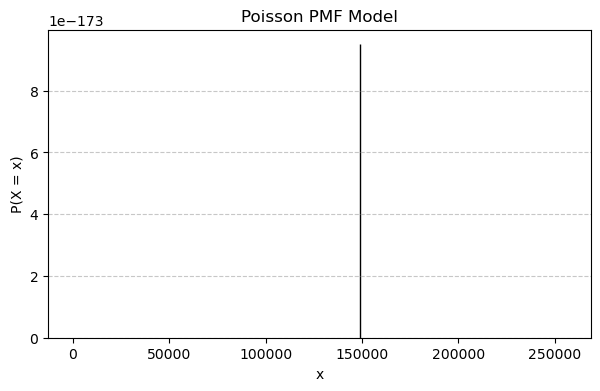

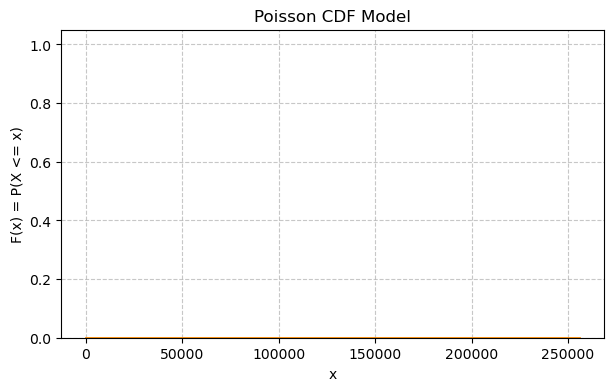

Observed mean: 160090.8947368421
Poisson theoretical mean: 160090.8947368421
Observed variance: 4661975302.099416
Poisson theoretical variance: 160090.8947368421


In [11]:
plot_pmf(x_values, poisson_pmf, "Poisson PMF Model")
plot_cdf(x_values, poisson_pmf, "Poisson CDF Model")

print("Observed mean:", observed_mean)
print("Poisson theoretical mean:", theoretical_mean)

print("Observed variance:", observed_variance)
print("Poisson theoretical variance:", theoretical_variance)

In [12]:
# 10. Define a binary request event and estimate its probability p. For groups of n requests, use a Binomial model
from math import comb

A = df["size"] > 1000
p = A.mean()

print("Number of requests:", len(df))
print("Number of events:", A.sum())
print("Estimated p:", p)

n = 10


k_values = np.arange(n+1)

pmf = np.array([comb(n,k) * (p**k) * ((1 - p) **(n-k)) for k in k_values])
binomial_table = display_distribution_table(k_values, pmf)
print(binomial_table)

# Exactly k events

k = 3
p_exactly_k = comb(n,k) * p**k * (1-p)**(n-k)
print("P(Y = 3) = ", p_exactly_k)

# no events

p_no_events = (1-p)**n
print("P(Y = 0) = ", p_no_events)

#At least one event
p_at_least_one = 1 - (1-p)**n
print("P(Y >= 1) = ", p_at_least_one)






Number of requests: 3041727
Number of events: 1740346
Estimated p: 0.5721571988544666
     x    P(X=x)  F(x)=P(X<=x)
0    0  0.000206      0.000206
1    1  0.002748      0.002954
2    2  0.016539      0.019493
3    3  0.058982      0.078475
4    4  0.138034      0.216509
5    5  0.221513      0.438021
6    6  0.246859      0.684880
7    7  0.188643      0.873524
8    8  0.094603      0.968126
9    9  0.028114      0.996240
10  10  0.003760      1.000000
P(Y = 3) =  0.058981654202600396
P(Y = 0) =  0.00020551441528849512
P(Y >= 1) =  0.9997944855847115


In [13]:
# 11. Define Y as the number of requests until the first occurrence of your selected event. Use a Geometric distribution to model Y and compare the theoretical and empirical means.


event = df["status"] == 200

# first occurances
first_event = np.where(event)[0]

Y = first_event[0] + 1
print("Y = " , Y)

p = event.mean()
theoretical_mean = 1 / p

print("p = " , p)
print("Theoretical geometric mean =", theoretical_mean)

pmf = np.array([(1 - p)**(k - 1) * p for k in event])

geometric_table = display_distribution_table(event, pmf)
geometric_table


Y =  554122
p =  7.561493848724754e-06
Theoretical geometric mean = 132249.0


,x,P(X=x),F(x)=P(X<=x)
0,False,0.000008,0.000008
1,False,0.000008,0.000015
2,False,0.000008,0.000023
3,False,0.000008,0.000030
4,False,0.000008,0.000038
...,...,...,...
3041722,False,0.000008,23.000144
3041723,False,0.000008,23.000151
3041724,False,0.000008,23.000159
3041725,False,0.000008,23.000166


In [14]:

#  12. Extend the previous question to the number of requests required to observe the third occurrence of the event. Identify the appropriate distribution and calculate its expected value.


# number of occurances
r = 3

# Excepted number of requests until the 3rd occurance
excepted_Y = r/p

print("Event probability p = ", p)
print("Expected requests until 3rd occurrence =", excepted_Y)


k_values = np.arange(r, 30)

pmf = np.array([
    comb(k - 1, r - 1) * p**r * (1 - p)**(k - r)
    for k in k_values
])

negative_binomial_table = pd.DataFrame({
    "k": k_values,
    "P(Y=k)": pmf
})

negative_binomial_table





Event probability p =  7.561493848724754e-06
Expected requests until 3rd occurrence = 396747.0


,k,P(Y=k)
0,3,4.323374e-16
1,4,1.297002e-15
2,5,2.593985e-15
3,6,4.323276e-15
4,7,6.484865e-15
5,8,9.078742e-15
6,9,1.210490e-14
7,10,1.556332e-14
8,11,1.945401e-14
9,12,2.377694e-14


# Part 3 - Continuous Random Variables and Distributions

In [15]:
from math import sqrt, pi, exp, erf, gamma, factorial


df["interarrival_time"] = df["timestamp"].diff()

df["minute"] = df["datetime"].dt.floor("min")
requests_per_minute = df.groupby("minute").size().reset_index(name="request_count")

print(df.head())
print(df.shape)

T = df["interarrival_time"].dropna()


   timestamp  client_id  object_id  size  method  status  type  server  \
0  895615201      14275       6219   546       0      66     1      99   
1  895615201       3817        233   631       0      66     1      99   
2  895615201      28686        981  3717       0      66     1      99   
3  895615201     385403        403   993       0      66     1      99   
4  895615201     403925         56  2140       0     130     1      99   

                   datetime  interarrival_time                    minute  
0 1998-05-19 22:00:01+00:00                NaN 1998-05-19 22:00:00+00:00  
1 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
2 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
3 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
4 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
(3041727, 11)


Approximate Mean: 0.02840393907932536
Approximate Variance: 0.027597155324103333
Standard Deviation: 0.16612391556938252
Median: 0.0
25th percentile: 0.0
75th percentile: 0.0
90th percentile: 0.0


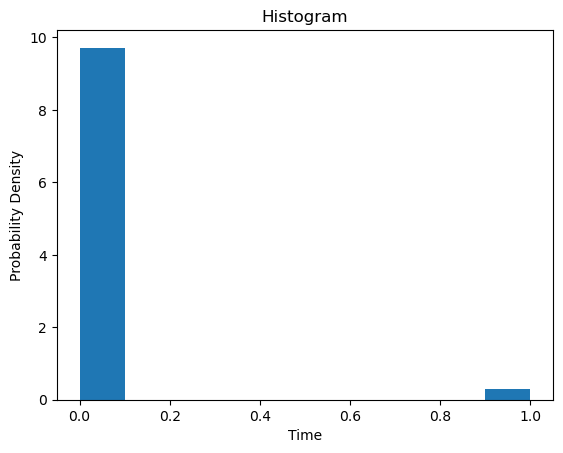

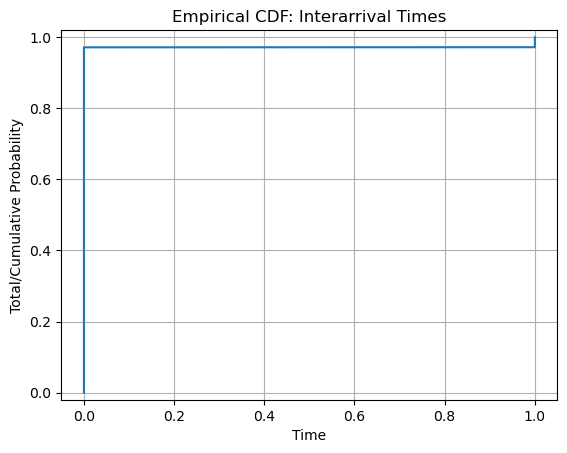

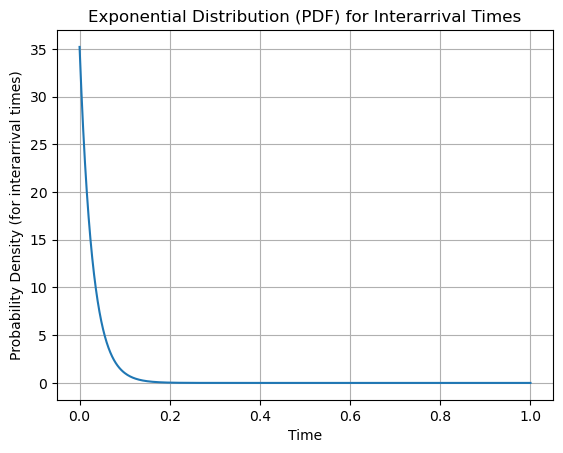

Mean: 0.02840393907932536
Variance: 0.0008067837552220261


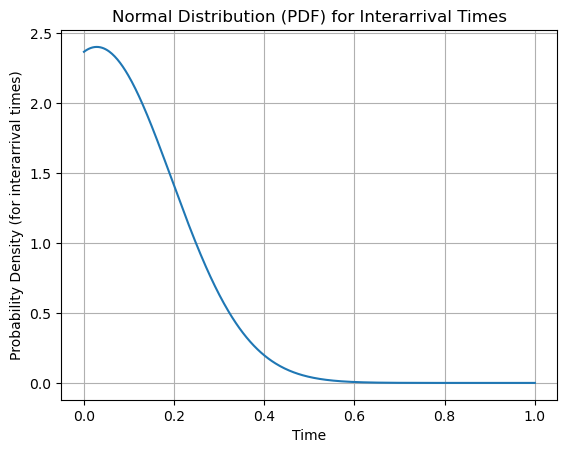

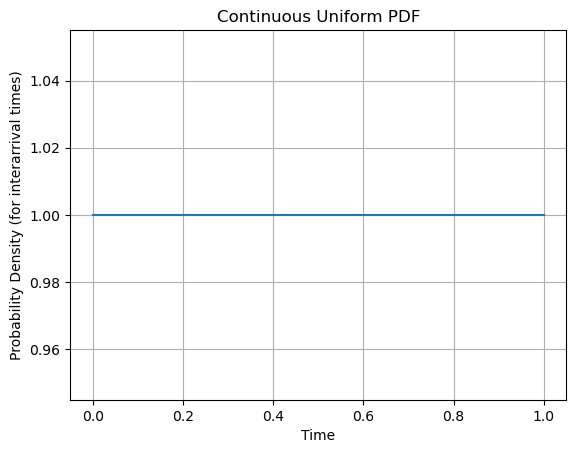

Combining:
Histogram
Exponential
Normal
Continuous Uniform


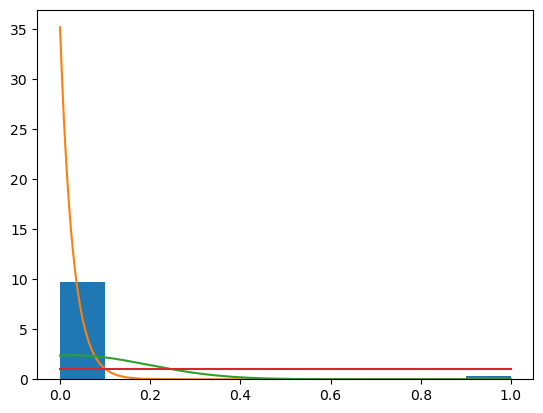

Estimated parameters are:
Exponential: 35.206384480942624
Normal: 0.02840393907932536 and 0.16612391556938252
Continuous Uniform: 0.0 and 1.0

The Exponential Distribution describes interarrival time most reasonably. The shape matches the histogram most closely with basically 
no observations at the far end on the right. The majority of observations on both of 
them are on the left near 0. Real web traffic may differ from idealized textbook models because real web traffic is not consistent unlike the textbook
would have you think. For example, instances of bursty traffic may occur suddenly because of, say, a large increase in interest from a recent popular 
advertisement. Similarly, DDOS attacks from hackers or bad actors trying to break the website or shut it down can be random and unpredictable, unlike 
textbook models. Textbook models don't account for the large variety of reasons web traffic can change!

P(T>t0)
Theoretical probability: 3.4083651739985424e-12
Empirical probability:

In [16]:

#Question 13

# Numerical approximation of mean and variance for interarrival time between consecutive requests 
# using Numpy


mean_approx = np.mean(T)
second_moment_approx = np.mean(T**2)
variance_approx = second_moment_approx - mean_approx**2
standard_deviation = np.sqrt(variance_approx)
median = np.median(T)
percentile_25 = np.percentile(T, 25)
percentile_75 = np.percentile(T, 75)
percentile_90 = np.percentile(T, 90)


print("Approximate Mean:", mean_approx)
print("Approximate Variance:", variance_approx)
print("Standard Deviation:", standard_deviation)
print("Median:", median)
print("25th percentile:", percentile_25)
print("75th percentile:", percentile_75)
print("90th percentile:", percentile_90)


#Plot the histogram, code from Statistical Practice 4
#Q15: Changes histogram to probability density to be able to compare to other graphs
plt.hist(T,bins = 10, density = True)
plt.xlabel("Time")
plt.ylabel("Probability Density")
plt.title("Histogram")
plt.show()



#Empirical CDF, from Statistical Practice 4
def plot_cdf(x, y, title):
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("Time")
    plt.ylabel("Total/Cumulative Probability")
    plt.title(title)
    plt.ylim(-0.02, 1.02)
    plt.grid(True)
    plt.show()

x = np.sort(T)

y = np.arange(1, len(x) + 1) / len(x)


plot_cdf(x, y, "Empirical CDF: Interarrival Times")


#Exponential Distribution, from Statistical Practice 4
# Exponential example
# A security monitoring system generates intrusion alerts at an average rate of 3 per hour.
# X = waiting time until the next alert, in hours.

def plot_pdf(x, y, title):
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("Time")
    plt.ylabel("Probability Density (for interarrival times)")
    plt.title(title)
    plt.grid(True)
    plt.show()


lam = 1/mean_approx

x = np.linspace(0, 1, 500)
expon_pdf = lam * np.exp(-lam * x)

plot_pdf(x, expon_pdf, "Exponential Distribution (PDF) for Interarrival Times")

print("Mean:", 1 / lam)
print("Variance:", 1 / lam**2)


#Normal Distribution, from Statistical Practice 4

def normal_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * sqrt(2 * pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

mu = mean_approx
sigma = standard_deviation

x = np.linspace(0, 1, 500)
norm_pdf = normal_pdf(x, mu, sigma)

plot_pdf(x, norm_pdf, "Normal Distribution (PDF) for Interarrival Times")


#Continuous Uniform Distribution, from Statistics Practice 4 and Numpy for parameters

a = np.min(T)
b = np.max(T)

x = np.linspace(0, 1, 500)
cont_pdf = np.where((x >= a) & (x <= b), 1/(b-a), 0)


plot_pdf(x, cont_pdf, "Continuous Uniform PDF")



#Overlay of all graphs
print("Combining:\nHistogram")
plt.hist(T,bins = 10, density = True)
print("Exponential")
plt.plot(x, expon_pdf)
print("Normal")
plt.plot(x,norm_pdf)
print("Continuous Uniform")
plt.plot(x,cont_pdf)
plt.show()
print("Estimated parameters are:")
print("Exponential:", lam)
print("Normal:", mu,"and", sigma)
print("Continuous Uniform:", a,"and",b)



#Q16
print("\nThe Exponential Distribution describes interarrival time most reasonably. The shape matches the histogram most closely with basically \nno observations at the far end on the right. The majority of observations on both of \nthem are on the left near 0. Real web traffic may differ from idealized textbook models because real web traffic is not consistent unlike the textbook\nwould have you think. For example, instances of bursty traffic may occur suddenly because of, say, a large increase in interest from a recent popular \nadvertisement. Similarly, DDOS attacks from hackers or bad actors trying to break the website or shut it down can be random and unpredictable, unlike \ntextbook models. Textbook models don't account for the large variety of reasons web traffic can change!")


#Q17
t0 = 0.75
#Adapted from Statistical Practice 4 code
theoretical_probability_one = np.exp(-lam * t0)
empirical_probability = np.mean(T > t0)
print("\nP(T>t0)")
print("Theoretical probability:", theoretical_probability_one)
print("Empirical probability:", empirical_probability)

t1 = 0.3
t2 = 0.9
theoretical_two = np.exp(-lam * t1) - np.exp(-lam * t2)
empirical_two = np.mean((T>t1) & (T<t2))
print("\nP(t1< T <t2)")
print("Theoretical:", theoretical_two)
print("Empirical:", empirical_two)


#Q18
print("\nA lognormal model would be reasonable to use because lognormal specifically have values above zero and display a distribution that is right skewed. \nThe data shown on the histogram is clearly skewed to the right with a long tail, with an even clearer showcase in the exponential model. ")


#Q19
print("\nUniform is not reasonable because the histogram is concentrated overwhelmingly at or around 0, with some observations at or near 1. \nUniform distributions should be used with data that has consistent probabilities across its x-axis (in this case time), and this histogram clearly does not have that.")



# Part 4 - Normal Approximations

#### Question 20 - Binomial and Normal Approximation

We use the binary event A from Part 1:

A = request belongs to category 1 (type == 1)

From the dataset:

P(A) = 0.8545326389

Let Z be the number of type 1 requests in a sample of n = 1000 requests.

We calculate P(Z >= 870) using:
1. The exact Binomial distribution
2. The Normal approximation with continuity correction

In [17]:
from scipy.stats import binom, norm, poisson
import numpy as np

# Binary event from Part 1
p = P_A

# Number of requests
n = 1000

# Minimum number of successes
k = 870

# Probability of failure
q = 1 - p

print("Binary event: request type == 1")
print("p =", p)
print("n =", n)
print("k =", k)

Binary event: request type == 1
p = 0.8545326388594374
n = 1000
k = 870


In [18]:
# Exact Binomial probability
exact_binomial = binom.sf(k - 1, n, p)

print("Exact Binomial P(Z >= k):", exact_binomial)

Exact Binomial P(Z >= k): 0.08825137843054597


In [19]:
mu = n * p
sigma = np.sqrt(n * p * q)

print("Mean (mu):", mu)
print("Standard deviation (sigma):", sigma)

Mean (mu): 854.5326388594374
Standard deviation (sigma): 11.149287330738396


In [20]:
continuity_value = k - 0.5

z_score = (continuity_value - mu) / sigma

normal_approx = norm.sf(z_score)

print("Continuity correction value:", continuity_value)
print("Z-score:", z_score)
print("Normal approximation P(Z >= k):", normal_approx)

Continuity correction value: 869.5
Z-score: 1.3424500325951647
Normal approximation P(Z >= k): 0.08972506072424441


In [21]:
difference = abs(exact_binomial - normal_approx)

print("Exact Binomial:", exact_binomial)
print("Normal approximation:", normal_approx)
print("Absolute difference:", difference)

Exact Binomial: 0.08825137843054597
Normal approximation: 0.08972506072424441
Absolute difference: 0.0014736822936984445


### Question 21 - Poisson and Normal Approximation

We use the number of requests arriving in a one-minute interval as
the random variable X.

The expected request count λ is estimated from the observed
one-minute request counts.

We calculate the probability of observing at least k requests in
one minute using:
1. The exact Poisson distribution
2. The Normal approximation

In [22]:
from scipy.stats import poisson as poisson_dist

In [23]:
# Estimate lambda from the average requests per minute
lambda_value = requests_per_minute["request_count"].mean()

# Choose a cutoff
k = int(np.ceil(lambda_value + 2 * np.sqrt(lambda_value)))

# Exact Poisson probability
exact_poisson = poisson_dist.sf(k - 1, lambda_value)

print("Lambda:", lambda_value)
print("k:", k)
print("Exact Poisson P(X >= k):", exact_poisson)

Lambda: 2112.3104166666667
k: 2205
Exact Poisson P(X >= k): 0.023013807310947404


In [24]:
# Normal approximation
mu_poisson = lambda_value
sigma_poisson = np.sqrt(lambda_value)

# Continuity correction
z_poisson = (k - 0.5 - mu_poisson) / sigma_poisson

normal_poisson = norm.sf(z_poisson)

print("Mean:", mu_poisson)
print("Standard deviation:", sigma_poisson)
print("Z-score:", z_poisson)
print("Normal approximation P(X >= k):", normal_poisson)

Mean: 2112.3104166666667
Standard deviation: 45.95987833607337
Z-score: 2.005870917655906
Normal approximation P(X >= k): 0.022435010915295987


In [25]:
# Compare the two probabilities
poisson_difference = abs(exact_poisson - normal_poisson)

print("Exact Poisson:", exact_poisson)
print("Normal approximation:", normal_poisson)
print("Absolute difference:", poisson_difference)

Exact Poisson: 0.023013807310947404
Normal approximation: 0.022435010915295987
Absolute difference: 0.0005787963956514174


### Interpretation

The exact Poisson distribution and the Normal approximation were used
to calculate the probability of observing at least k requests in a
one-minute interval. The difference between the two results shows how
closely the Normal approximation matches the exact Poisson probability.
Since the expected request count λ is sufficiently large, the Normal
approximation provides a reasonable approximation.